In [44]:
import pandas as pd
import os
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

BASE_PROJECT_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

exp1a_path = os.path.join(
    BASE_PROJECT_PATH, "20_experiments/60_analyses/csv_files/quantitative/exp1a.csv"
)
exp1b_path = os.path.join(
    BASE_PROJECT_PATH, "20_experiments/60_analyses/csv_files/quantitative/exp1b.csv"
)

output_dir_exp1a = os.path.join(
    BASE_PROJECT_PATH, "40_evaluation/exp1/quantitative/tables/exp1a"
)
output_dir_exp1b = os.path.join(
    BASE_PROJECT_PATH, "40_evaluation/exp1/quantitative/tables/exp1b"
)
output_plot_dir_exp1a = os.path.join(
    BASE_PROJECT_PATH, "40_evaluation/exp1/quantitative/plots/exp1a"
)
output_plot_dir_exp1b = os.path.join(
    BASE_PROJECT_PATH, "40_evaluation/exp1/quantitative/plots/exp1b"
)

tables = {}
plots = {}

for path in [output_dir_exp1a, output_dir_exp1b, output_plot_dir_exp1a, output_plot_dir_exp1b]:
    os.makedirs(path, exist_ok=True)

if not os.path.exists(exp1a_path) or not os.path.exists(exp1b_path):
    print("Error: Quantitative data files not found.")
    print(f"Looked for {exp1a_path} and {exp1b_path}")
else:
    exp1a_df = pd.read_csv(exp1a_path)
    exp1b_df = pd.read_csv(exp1b_path)

    # Combine adherence scores into a single metric
    exp1a_df["adherence_score"] = exp1a_df[
        ["adherence_score_openai", "adherence_score_anthropic"]
    ].mean(axis=1)
    exp1b_df["adherence_score"] = exp1b_df[
        ["adherence_score_openai", "adherence_score_anthropic"]
    ].mean(axis=1)

    # Drop original adherence scores
    exp1a_df = exp1a_df.drop(
        columns=["adherence_score_openai", "adherence_score_anthropic"]
    )
    exp1b_df = exp1b_df.drop(
        columns=["adherence_score_openai", "adherence_score_anthropic"]
    )
    print("Data loaded and preprocessed for exp1a and exp1b.")

Data loaded and preprocessed for exp1a and exp1b.


## Experiment 1a

### 1.1: Metrics by LLM

In [45]:
llm_metrics_1a = exp1a_df.groupby("llm")[["cosine_similarity", "adherence_score"]].agg(
    ["mean", "std"]
)
tables["exp1a_metrics_by_llm"] = llm_metrics_1a
display(llm_metrics_1a)

cosine_similarity           adherence_score          
                       mean       std            mean       std
llm                                                            
anthropic          0.578823  0.136459        0.935238  0.110993
deepseek           0.490059  0.142076        0.958690  0.049879
google             0.634277  0.142834        0.940714  0.079300
openai             0.543139  0.154746        0.965833  0.083731

### 1.2: Metrics by Input Source

In [46]:
input_source_metrics_1a = exp1a_df.groupby("input_source")[
    ["cosine_similarity", "adherence_score"]
].agg(["mean", "std"])
tables["exp1a_metrics_by_input_source"] = input_source_metrics_1a
display(input_source_metrics_1a)

cosine_similarity           adherence_score          
                          mean       std            mean       std
input_source                                                      
script                0.637166  0.107065        0.947054  0.075364
tanenbaum             0.551117  0.131404        0.951696  0.092713
transcript            0.496441  0.177308        0.951607  0.084521

### 1.3: Metrics by Prompt Type

In [47]:
prompt_type_metrics_1a = exp1a_df.groupby("prompt_type")[
    ["cosine_similarity", "adherence_score"]
].agg(["mean", "std"])
tables["exp1a_metrics_by_prompt_type"] = prompt_type_metrics_1a
display(prompt_type_metrics_1a)

cosine_similarity           adherence_score          
                         mean       std            mean       std
prompt_type                                                      
common               0.539460  0.166316        0.978571  0.055077
complex              0.583689  0.134205        0.921667  0.097626

### 1.4: Metrics by Layer

In [48]:
layer_metrics_1a = exp1a_df.groupby("layer")[["cosine_similarity", "adherence_score"]].agg(
    ["mean", "std"]
)
tables["exp1a_metrics_by_layer"] = layer_metrics_1a
display(layer_metrics_1a)

cosine_similarity           adherence_score          
                   mean       std            mean       std
layer                                                      
1              0.544263  0.136847        0.953333  0.089475
2              0.541102  0.188342        0.965000  0.047204
3              0.506294  0.180749        0.952708  0.062171
4              0.516466  0.191584        0.942083  0.085197
5              0.570953  0.096305        0.964375  0.050440
6              0.584212  0.083876        0.958750  0.085214
7              0.667732  0.100277        0.914583  0.134786

In [86]:
import os
import glob
import re

def extract_info_from_path(file_path):
    """Extract input_source, layer, llm, and prompt_type from file path"""
    # Example path: .../run_a_content/common_prompt/anthropic/script/layer1_question.txt
    parts = file_path.split(os.sep)
    
    input_source = None
    layer = None
    llm = None
    prompt_type = None
    
    # Find the relevant components in path
    for i, part in enumerate(parts):
        if part in ['common_prompt', 'complex_prompt']:
            prompt_type = 'common' if part == 'common_prompt' else 'complex'
            # LLM should be the next part
            if i + 1 < len(parts):
                llm = parts[i + 1]
            # Input source should be after LLM
            if i + 2 < len(parts):
                input_source = parts[i + 2]
            # Layer is in the filename
            if i + 3 < len(parts):
                filename = parts[i + 3]
                if 'layer' in filename:
                    layer_match = re.search(r'layer(\d+)', filename)
                    if layer_match:
                        layer = f"layer{layer_match.group(1)}"
            break
    
    return input_source, layer, llm, prompt_type

def find_free_text_questions_with_scores():
    free_text_data = []
    
    base_path = os.path.join(BASE_PROJECT_PATH, "20_experiments/10_exp1")
    all_files = glob.glob(os.path.join(base_path, "**/*.txt"), recursive=True)
    
    for file_path in all_files:
        if "_question.txt" in file_path:
            try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    content = f.read()
                
                # Check if it's a free text question (has "Antwort:" but no "Antwortmöglichkeiten:")
                if "Antwort:" in content and "Antwortmöglichkeiten:" not in content:
                    # Extract info from path
                    input_source, layer, llm_file, prompt_type = extract_info_from_path(file_path)
                    
                    # Map file LLM names to CSV LLM names
                    llm_mapping = {
                        'anthropic': 'anthropic',
                        'openai': 'openai', 
                        'google': 'google',
                        'deepseek': 'deepseek'
                    }
                    
                    llm = llm_mapping.get(llm_file, llm_file)
                    
                    # Determine which dataframe to use and adjust input_source
                    df = None
                    experiment = None
                    if "run_a_content" in file_path:
                        df = exp1a_df
                        experiment = "Exp1a"
                        # For exp1a, input_source stays as is
                    elif "run_b_error" in file_path:
                        df = exp1b_df
                        experiment = "Exp1b"
                        # For exp1b, script becomes script_manipulated in CSV
                        if input_source == 'script':
                            input_source = 'script_manipulated'
                    
                    # Find matching row in dataframe
                    cosine_sim = None
                    adherence_score = None
                    
                    if df is not None and input_source and layer and llm and prompt_type:
                        # Try to find exact match
                        matching_rows = df[
                            (df['input_source'] == input_source) & 
                            (df['layer'] == layer) & 
                            (df['llm'] == llm) & 
                            (df['prompt_type'] == prompt_type)
                        ]
                        
                        if not matching_rows.empty:
                            # Use the exact match
                            cosine_sim = matching_rows['cosine_similarity'].iloc[0]
                            adherence_score = matching_rows['adherence_score'].iloc[0]
                        else:
                            # Fallback: find by input_source and layer, average across LLMs/prompt_types
                            fallback_rows = df[
                                (df['input_source'] == input_source) & 
                                (df['layer'] == layer)
                            ]
                            if not fallback_rows.empty:
                                cosine_sim = fallback_rows['cosine_similarity'].mean()
                                adherence_score = fallback_rows['adherence_score'].mean()
                    
                    free_text_data.append({
                        'path': file_path,
                        'experiment': experiment,
                        'input_source': input_source,
                        'layer': layer,
                        'llm': llm,
                        'prompt_type': prompt_type,
                        'cosine_similarity': cosine_sim,
                        'adherence_score': adherence_score
                    })
            except Exception as e:
                print(f"Error processing {file_path}: {e}")
                pass
    
    return sorted(free_text_data, key=lambda x: x['path'])

def count_total_questions():
    """Zähle alle Fragen in 10_exp1"""
    base_path = os.path.join(BASE_PROJECT_PATH, "20_experiments/10_exp1")
    all_files = glob.glob(os.path.join(base_path, "**/*.txt"), recursive=True)
    
    exp1a_total = 0
    exp1b_total = 0
    
    for file_path in all_files:
        if "_question.txt" in file_path:
            if "run_a_content" in file_path:
                exp1a_total += 1
            elif "run_b_error" in file_path:
                exp1b_total += 1
    
    return exp1a_total, exp1b_total

# Get data with scores
free_text_data = find_free_text_questions_with_scores()
exp1a_total, exp1b_total = count_total_questions()

print("Free Text Questions with Scores:")
print("=" * 80)

exp1a_count = 0
exp1b_count = 0

for item in free_text_data:
    print(f"\nFile: {item['path']}")
    print(f"Experiment: {item['experiment']}")
    print(f"Input Source: {item['input_source']} | Layer: {item['layer']} | LLM: {item['llm']} | Prompt: {item['prompt_type']}")
    
    if item['cosine_similarity'] is not None:
        print(f"Cosine Similarity: {item['cosine_similarity']:.4f}")
    else:
        print("Cosine Similarity: Not found")
    
    if item['adherence_score'] is not None:
        print(f"Adherence Score: {item['adherence_score']:.4f}")
    else:
        print("Adherence Score: Not found")
    
    if item['experiment'] == "Exp1a":
        exp1a_count += 1
    elif item['experiment'] == "Exp1b":
        exp1b_count += 1

print(f"\n" + "=" * 80)
print(f"SUMMARY:")
print(f"Free Text Questions:")
print(f"  Exp1a (run_a_content): {exp1a_count}")
print(f"  Exp1b (run_b_error): {exp1b_count}")
print(f"  Total Free Text: {len(free_text_data)}")

print(f"\nTotal Questions (All Types):")
print(f"  Exp1a (run_a_content): {exp1a_total}")
print(f"  Exp1b (run_b_error): {exp1b_total}")
print(f"  Total All Questions: {exp1a_total + exp1b_total}")

print(f"\nPercentages:")
if exp1a_total > 0:
    print(f"  Exp1a Free Text: {exp1a_count}/{exp1a_total} ({100*exp1a_count/exp1a_total:.1f}%)")
if exp1b_total > 0:
    print(f"  Exp1b Free Text: {exp1b_count}/{exp1b_total} ({100*exp1b_count/exp1b_total:.1f}%)")
if (exp1a_total + exp1b_total) > 0:
    print(f"  Overall Free Text: {len(free_text_data)}/{exp1a_total + exp1b_total} ({100*len(free_text_data)/(exp1a_total + exp1b_total):.1f}%)")

Free Text Questions with Scores:

File: /home/malde/git/bachelor-thesis/20_experiments/10_exp1/run_a_content/complex_prompt/google/tanenbaum/layer2_question.txt
Experiment: Exp1a
Input Source: tanenbaum | Layer: layer2 | LLM: google | Prompt: complex
Cosine Similarity: Not found
Adherence Score: Not found

File: /home/malde/git/bachelor-thesis/20_experiments/10_exp1/run_a_content/complex_prompt/google/transcript/layer3_question.txt
Experiment: Exp1a
Input Source: transcript | Layer: layer3 | LLM: google | Prompt: complex
Cosine Similarity: Not found
Adherence Score: Not found

File: /home/malde/git/bachelor-thesis/20_experiments/10_exp1/run_a_content/complex_prompt/openai/script/layer1_question.txt
Experiment: Exp1a
Input Source: script | Layer: layer1 | LLM: openai | Prompt: complex
Cosine Similarity: Not found
Adherence Score: Not found

File: /home/malde/git/bachelor-thesis/20_experiments/10_exp1/run_a_content/complex_prompt/openai/script/layer5_question.txt
Experiment: Exp1a
Input 

### 1.5: Cosine Similarity: LLM vs Input Source

In [52]:
llm_vs_input_source_cos_sim_1a = pd.pivot_table(
    exp1a_df,
    values="cosine_similarity",
    index="llm",
    columns="input_source",
    aggfunc=["mean", "std"],
)
tables["exp1a_cosine_sim_llm_vs_input_source"] = llm_vs_input_source_cos_sim_1a
display(llm_vs_input_source_cos_sim_1a)

mean                            std                     
input_source    script tanenbaum transcript    script tanenbaum transcript
llm                                                                       
anthropic     0.665448  0.558400   0.512622  0.083972  0.127495   0.148904
deepseek      0.583646  0.487522   0.399008  0.115115  0.129716   0.123360
google        0.674851  0.618073   0.609906  0.126135  0.101522   0.188233
openai        0.624718  0.540471   0.464228  0.081499  0.142488   0.186273

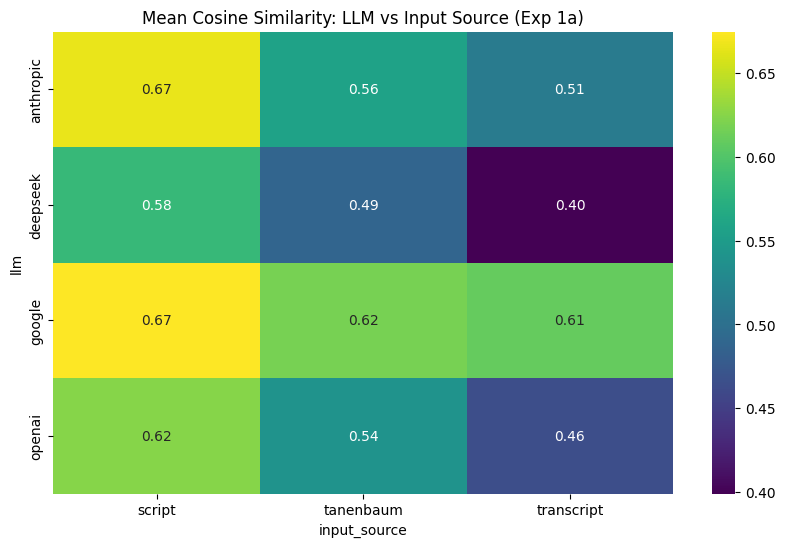

In [53]:

fig, ax = plt.subplots(figsize=(10, 6))
plots['exp1a_cosine_sim_llm_vs_input_source'] = fig
sns.heatmap(llm_vs_input_source_cos_sim_1a["mean"], annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Mean Cosine Similarity: LLM vs Input Source (Exp 1a)")
plt.show()


### 1.6: Cosine Similarity: LLM vs Prompt Type

In [54]:
llm_vs_prompt_type_cos_sim_1a = pd.pivot_table(
    exp1a_df,
    values="cosine_similarity",
    index="llm",
    columns="prompt_type",
    aggfunc=["mean", "std"],
)
tables["exp1a_cosine_sim_llm_vs_prompt_type"] = llm_vs_prompt_type_cos_sim_1a
display(llm_vs_prompt_type_cos_sim_1a)

mean                 std          
prompt_type    common   complex    common   complex
llm                                                
anthropic    0.583207  0.574440  0.166589  0.101888
deepseek     0.485833  0.494285  0.141371  0.146142
google       0.580096  0.688457  0.158760  0.102245
openai       0.508703  0.577575  0.184646  0.111829

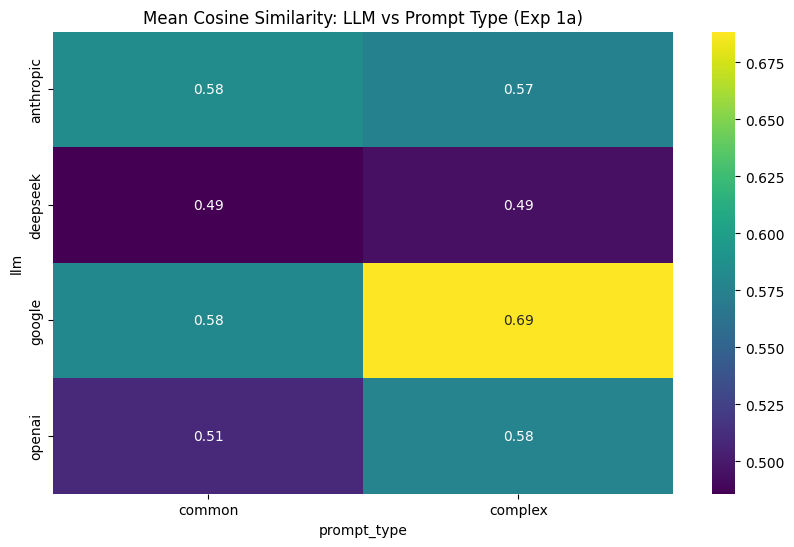

In [55]:

fig, ax = plt.subplots(figsize=(10, 6))
plots['exp1a_cosine_sim_llm_vs_prompt_type'] = fig
sns.heatmap(llm_vs_prompt_type_cos_sim_1a["mean"], annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Mean Cosine Similarity: LLM vs Prompt Type (Exp 1a)")
plt.show()


### 1.7: Adherence Score: LLM vs Prompt Type

In [56]:
llm_vs_prompt_type_adherence_1a = pd.pivot_table(
    exp1a_df,
    values="adherence_score",
    index="llm",
    columns="prompt_type",
    aggfunc=["mean", "std"],
)
tables["exp1a_adherence_llm_vs_prompt_type"] = llm_vs_prompt_type_adherence_1a
display(llm_vs_prompt_type_adherence_1a)

mean                 std          
prompt_type    common   complex    common   complex
llm                                                
anthropic    0.972619  0.897857  0.093843  0.116249
deepseek     0.972619  0.944762  0.036797  0.057781
google       0.977381  0.904048  0.043778  0.090286
openai       0.991667  0.940000  0.015995  0.112761

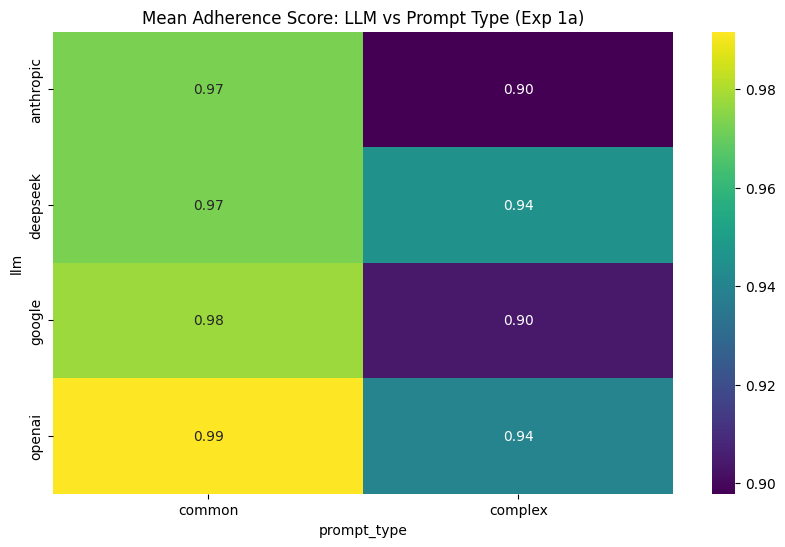

In [57]:

fig, ax = plt.subplots(figsize=(10, 6))
plots['exp1a_adherence_llm_vs_prompt_type'] = fig
sns.heatmap(llm_vs_prompt_type_adherence_1a["mean"], annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Mean Adherence Score: LLM vs Prompt Type (Exp 1a)")
plt.show()


### 1.8: Adherence Score: LLM vs Input Source

In [58]:
llm_vs_input_source_adherence_1a = pd.pivot_table(
    exp1a_df,
    values="adherence_score",
    index="llm",
    columns="input_source",
    aggfunc=["mean", "std"],
)
tables["exp1a_adherence_llm_vs_input_source"] = llm_vs_input_source_adherence_1a
display(llm_vs_input_source_adherence_1a)

mean                            std                     
input_source    script tanenbaum transcript    script tanenbaum transcript
llm                                                                       
anthropic     0.914286  0.946429   0.945000  0.115806  0.111017   0.111390
deepseek      0.944286  0.965714   0.966071  0.066762  0.043847   0.033637
google        0.952857  0.948571   0.920714  0.051168  0.054647   0.116501
openai        0.976786  0.946071   0.974643  0.037293  0.137284   0.035217

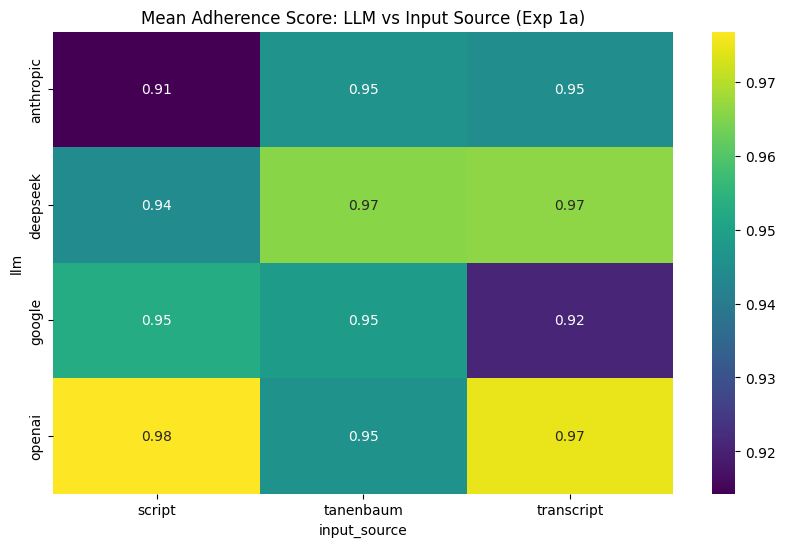

In [59]:

fig, ax = plt.subplots(figsize=(10, 6))
plots['exp1a_adherence_llm_vs_input_source'] = fig
sns.heatmap(llm_vs_input_source_adherence_1a["mean"], annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Mean Adherence Score: LLM vs Input Source (Exp 1a)")
plt.show()


### 1.9: Distribution Plots

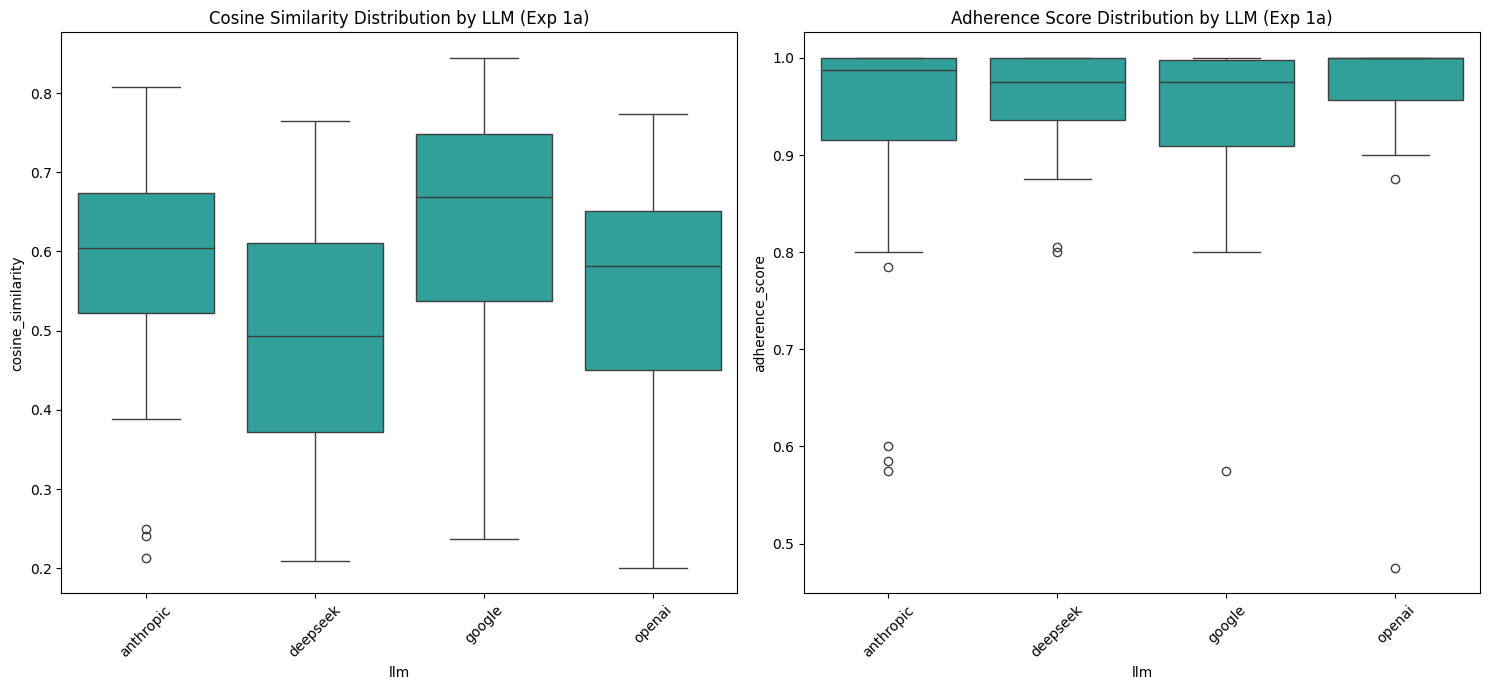

In [60]:
# Boxplot for cosine_similarity and adherence_score by LLM
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plots['exp1a_dist_by_llm'] = fig

sns.boxplot(x='llm', y='cosine_similarity', data=exp1a_df, ax=ax[0], color='lightseagreen')
ax[0].set_title('Cosine Similarity Distribution by LLM (Exp 1a)')
ax[0].tick_params(axis='x', rotation=45)

sns.boxplot(x='llm', y='adherence_score', data=exp1a_df, ax=ax[1], color='lightseagreen')
ax[1].set_title('Adherence Score Distribution by LLM (Exp 1a)')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


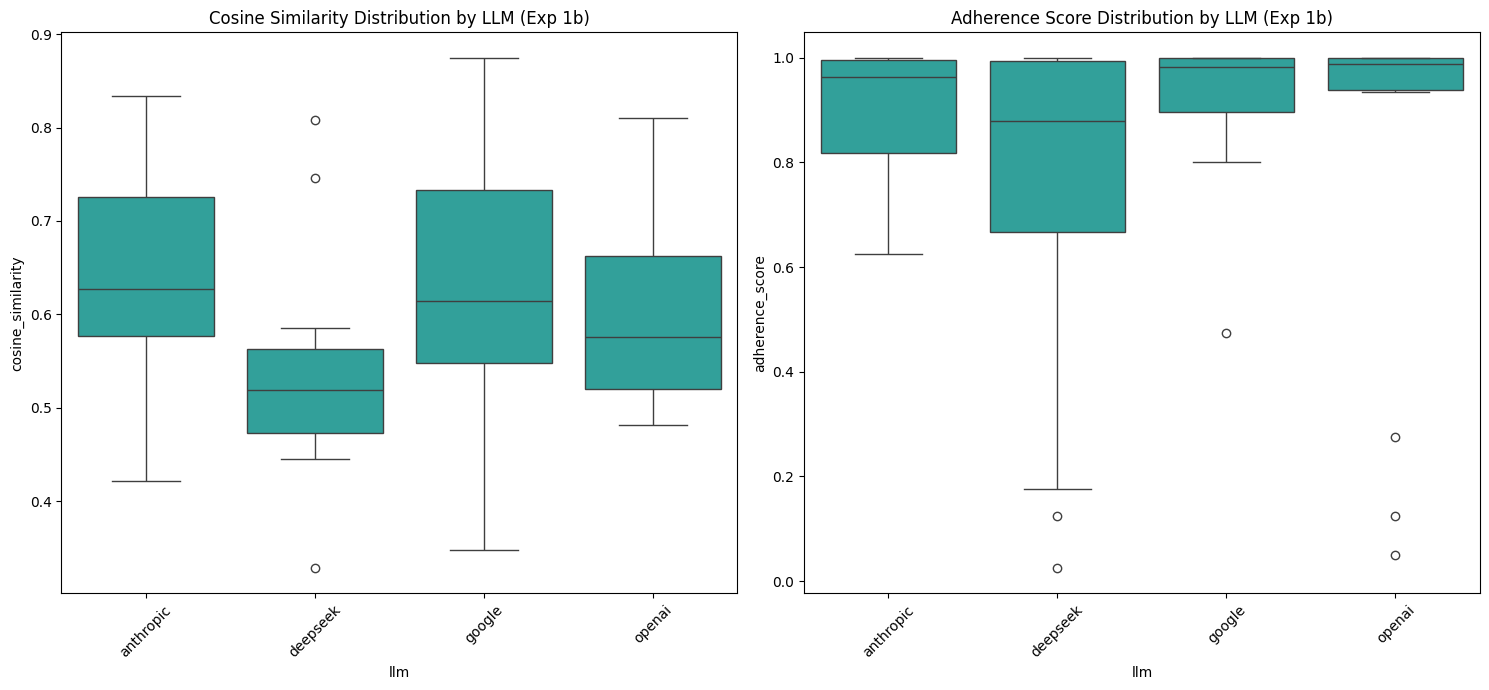

In [61]:
# Boxplot for cosine_similarity and adherence_score by LLM
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plots['exp1b_dist_by_llm'] = fig

sns.boxplot(x='llm', y='cosine_similarity', data=exp1b_df, ax=ax[0], color='lightseagreen')
ax[0].set_title('Cosine Similarity Distribution by LLM (Exp 1b)')
ax[0].tick_params(axis='x', rotation=45)

sns.boxplot(x='llm', y='adherence_score', data=exp1b_df, ax=ax[1], color='lightseagreen')
ax[1].set_title('Adherence Score Distribution by LLM (Exp 1b)')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


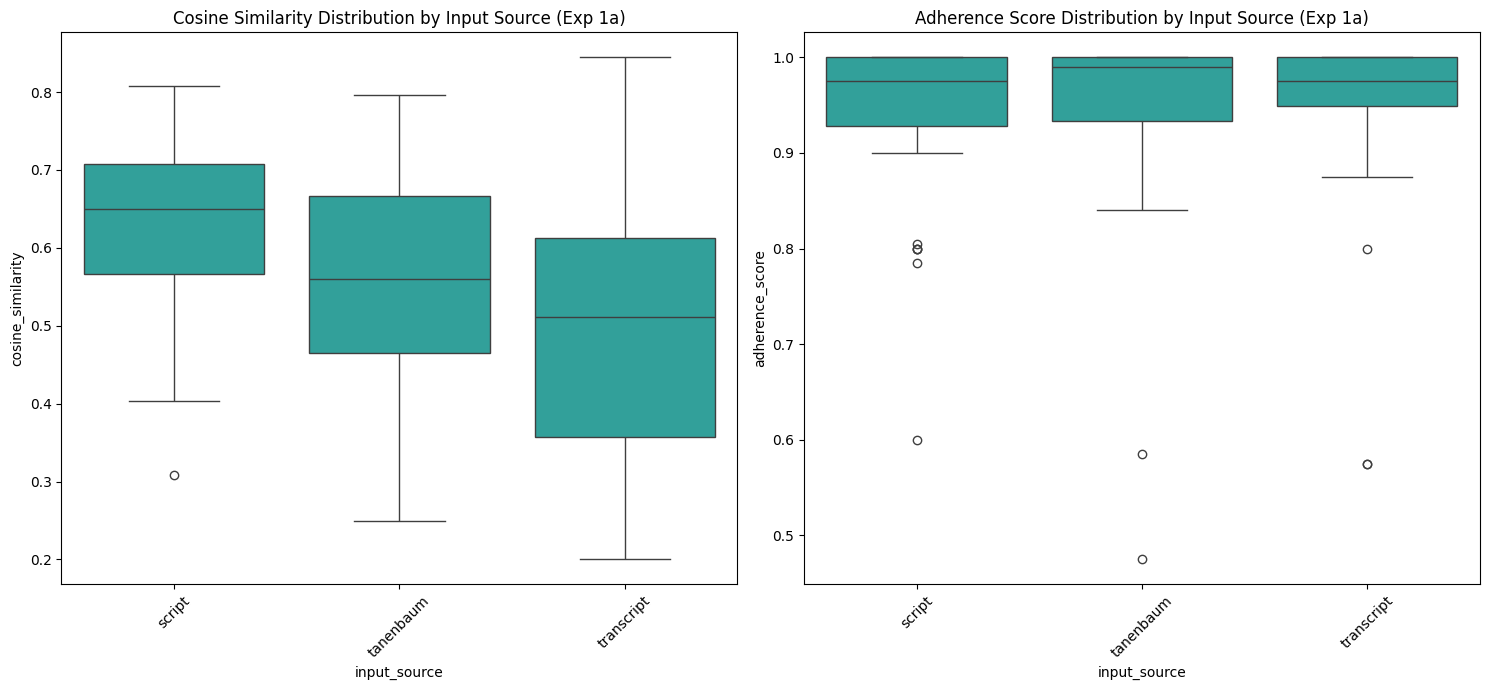

In [62]:
# Boxplot for cosine_similarity and adherence_score by input_source
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plots['exp1a_dist_by_input_source'] = fig

sns.boxplot(x='input_source', y='cosine_similarity', data=exp1a_df, ax=ax[0], color='lightseagreen')
ax[0].set_title('Cosine Similarity Distribution by Input Source (Exp 1a)')
ax[0].tick_params(axis='x', rotation=45)

sns.boxplot(x='input_source', y='adherence_score', data=exp1a_df, ax=ax[1], color='lightseagreen')
ax[1].set_title('Adherence Score Distribution by Input Source (Exp 1a)')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

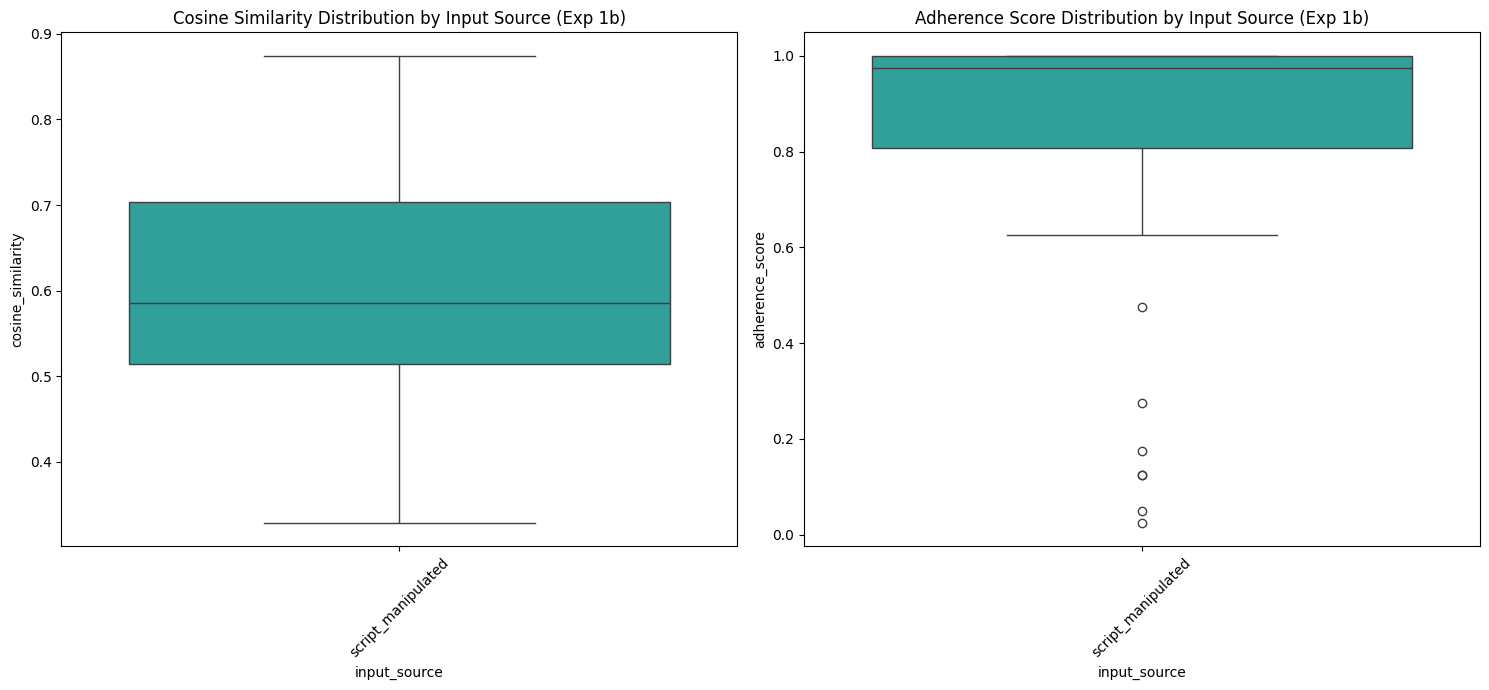

In [63]:
# Boxplot for cosine_similarity and adherence_score by input_source
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plots['exp1b_dist_by_input_source'] = fig

sns.boxplot(x='input_source', y='cosine_similarity', data=exp1b_df, ax=ax[0], color='lightseagreen')
ax[0].set_title('Cosine Similarity Distribution by Input Source (Exp 1b)')
ax[0].tick_params(axis='x', rotation=45)

sns.boxplot(x='input_source', y='adherence_score', data=exp1b_df, ax=ax[1], color='lightseagreen')
ax[1].set_title('Adherence Score Distribution by Input Source (Exp 1b)')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

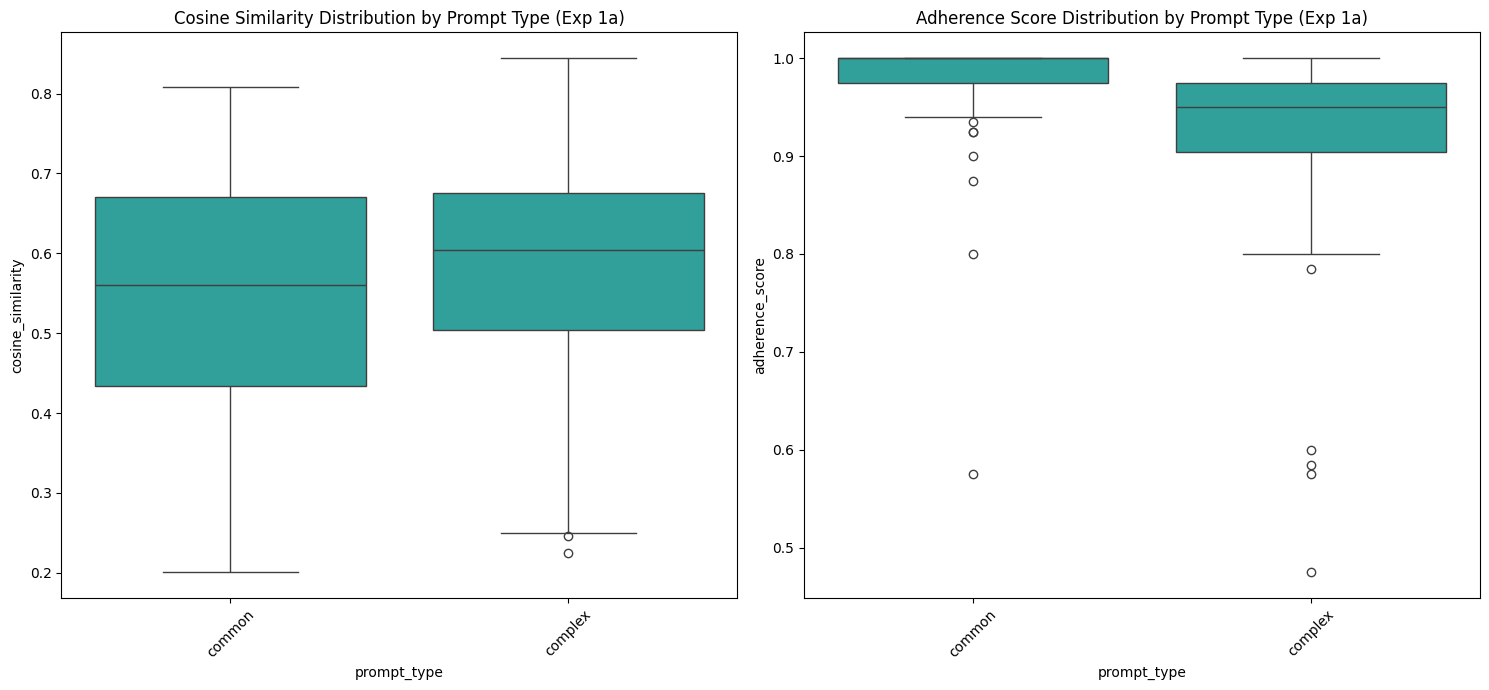

In [64]:
# Boxplot for cosine_similarity and adherence_score by prompt_type
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plots['exp1a_dist_by_prompt_type'] = fig

sns.boxplot(x='prompt_type', y='cosine_similarity', data=exp1a_df, ax=ax[0], color='lightseagreen')
ax[0].set_title('Cosine Similarity Distribution by Prompt Type (Exp 1a)')
ax[0].tick_params(axis='x', rotation=45)

sns.boxplot(x='prompt_type', y='adherence_score', data=exp1a_df, ax=ax[1], color='lightseagreen')
ax[1].set_title('Adherence Score Distribution by Prompt Type (Exp 1a)')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

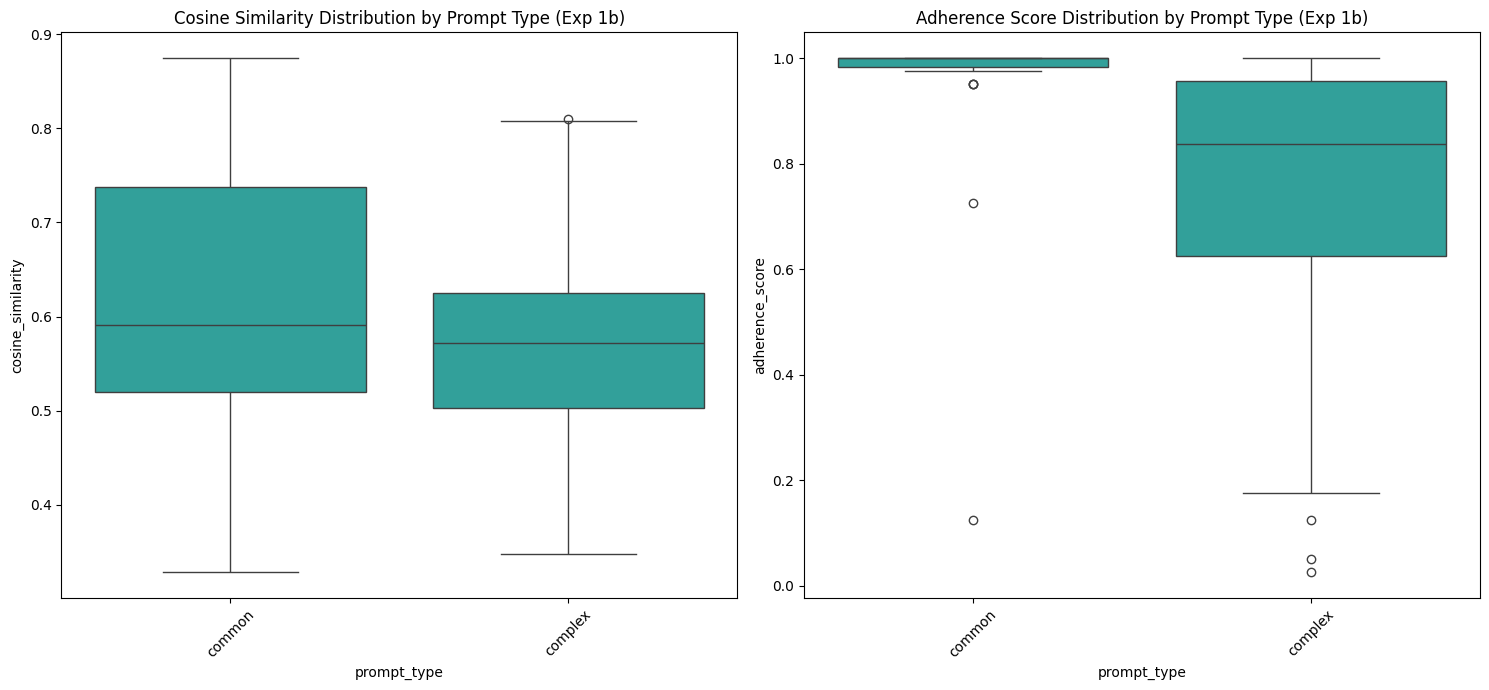

In [65]:
# Boxplot for cosine_similarity and adherence_score by prompt_type
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plots['exp1b_dist_by_prompt_type'] = fig

sns.boxplot(x='prompt_type', y='cosine_similarity', data=exp1b_df, ax=ax[0], color='lightseagreen')
ax[0].set_title('Cosine Similarity Distribution by Prompt Type (Exp 1b)')
ax[0].tick_params(axis='x', rotation=45)

sns.boxplot(x='prompt_type', y='adherence_score', data=exp1b_df, ax=ax[1], color='lightseagreen')
ax[1].set_title('Adherence Score Distribution by Prompt Type (Exp 1b)')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

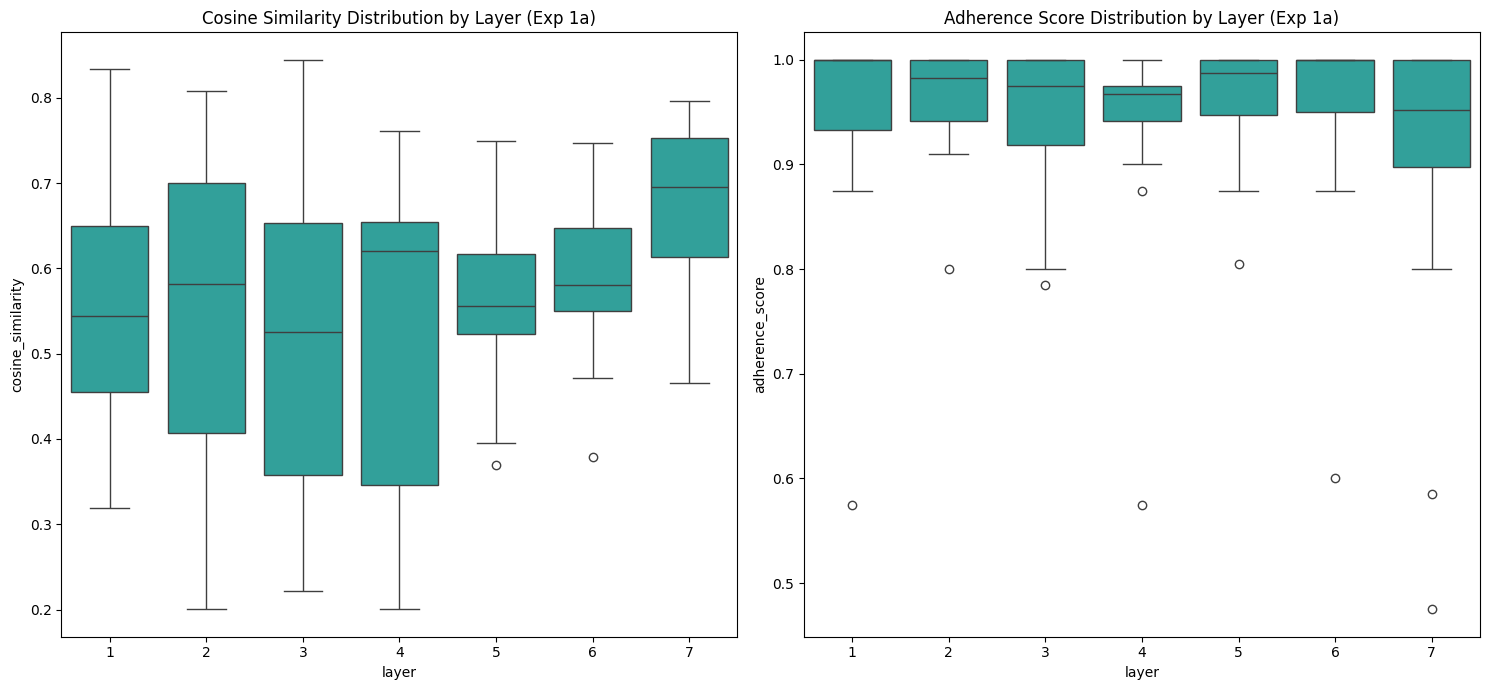

In [66]:
# Boxplot for cosine_similarity and adherence_score by layer
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plots['exp1a_dist_by_layer'] = fig

sns.boxplot(x='layer', y='cosine_similarity', data=exp1a_df, ax=ax[0], color='lightseagreen')
ax[0].set_title('Cosine Similarity Distribution by Layer (Exp 1a)')
ax[0].tick_params(axis='x', rotation=0)

sns.boxplot(x='layer', y='adherence_score', data=exp1a_df, ax=ax[1], color='lightseagreen')
ax[1].set_title('Adherence Score Distribution by Layer (Exp 1a)')
ax[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

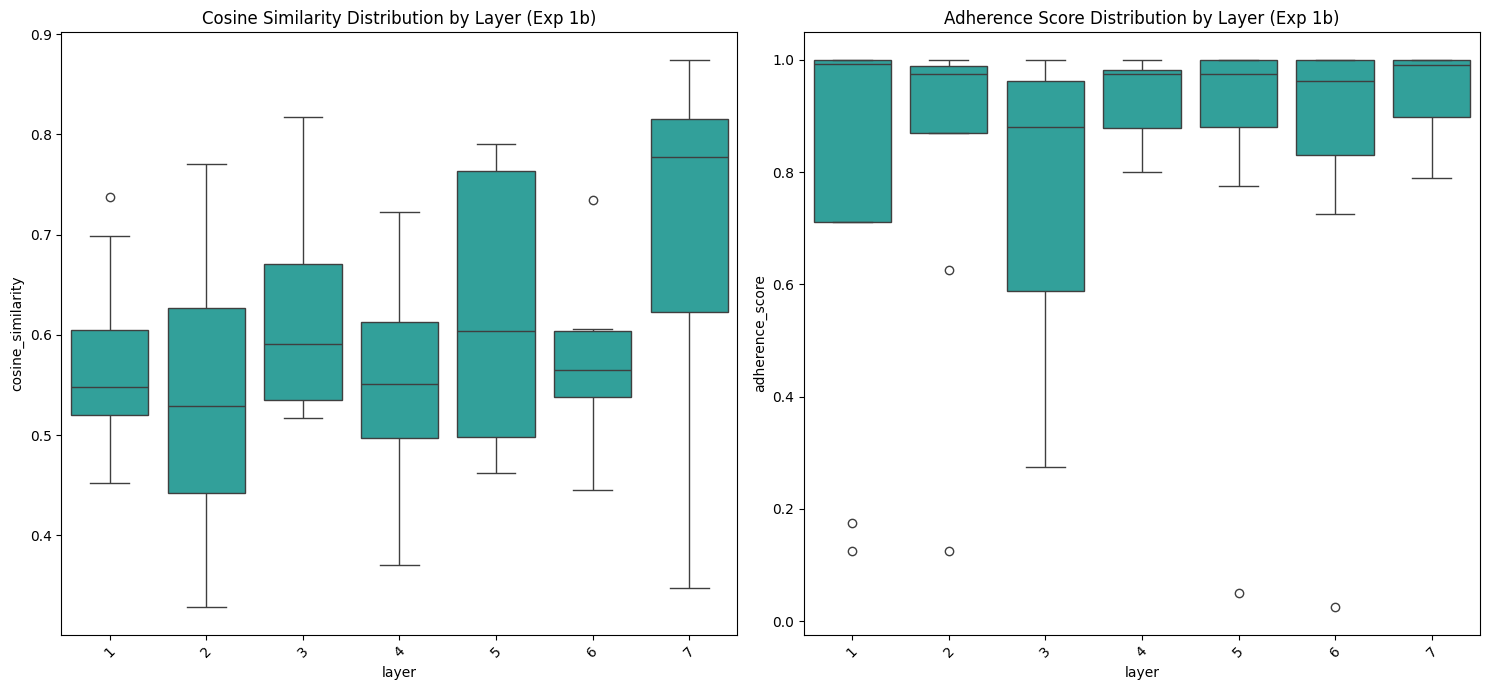

In [67]:
# Boxplot for cosine_similarity and adherence_score by layer
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plots['exp1b_dist_by_layer'] = fig

sns.boxplot(x='layer', y='cosine_similarity', data=exp1b_df, ax=ax[0], color='lightseagreen')
ax[0].set_title('Cosine Similarity Distribution by Layer (Exp 1b)')
ax[0].tick_params(axis='x', rotation=45)

sns.boxplot(x='layer', y='adherence_score', data=exp1b_df, ax=ax[1], color='lightseagreen')
ax[1].set_title('Adherence Score Distribution by Layer (Exp 1b)')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [68]:
# # Boxplot for cosine_similarity and adherence_score by question_type
# fig, ax = plt.subplots(1, 2, figsize=(15, 7))
# plots['exp1a_dist_by_question_type'] = fig

# sns.boxplot(x='question_type', y='cosine_similarity', data=exp1a_df, ax=ax[0], color='lightcoral')
# ax[0].set_title('Cosine Similarity Distribution by Question Type (Exp 1a)')
# ax[0].tick_params(axis='x', rotation=45)

# sns.boxplot(x='question_type', y='adherence_score', data=exp1a_df, ax=ax[1], color='lightcoral')
# ax[1].set_title('Adherence Score Distribution by Question Type (Exp 1a)')
# ax[1].tick_params(axis='x', rotation=45)

# plt.tight_layout()
# plt.show()

In [69]:
# # Boxplot for cosine_similarity and adherence_score by question_type
# fig, ax = plt.subplots(1, 2, figsize=(15, 7))
# plots['exp1b_dist_by_question_type'] = fig

# sns.boxplot(x='question_type', y='cosine_similarity', data=exp1b_df, ax=ax[0], color='lightcoral')
# ax[0].set_title('Cosine Similarity Distribution by Question Type (Exp 1b)')
# ax[0].tick_params(axis='x', rotation=45)

# sns.boxplot(x='question_type', y='adherence_score', data=exp1b_df, ax=ax[1], color='lightcoral')
# ax[1].set_title('Adherence Score Distribution by Question Type (Exp 1b)')
# ax[1].tick_params(axis='x', rotation=45)

# plt.tight_layout()
# plt.show()

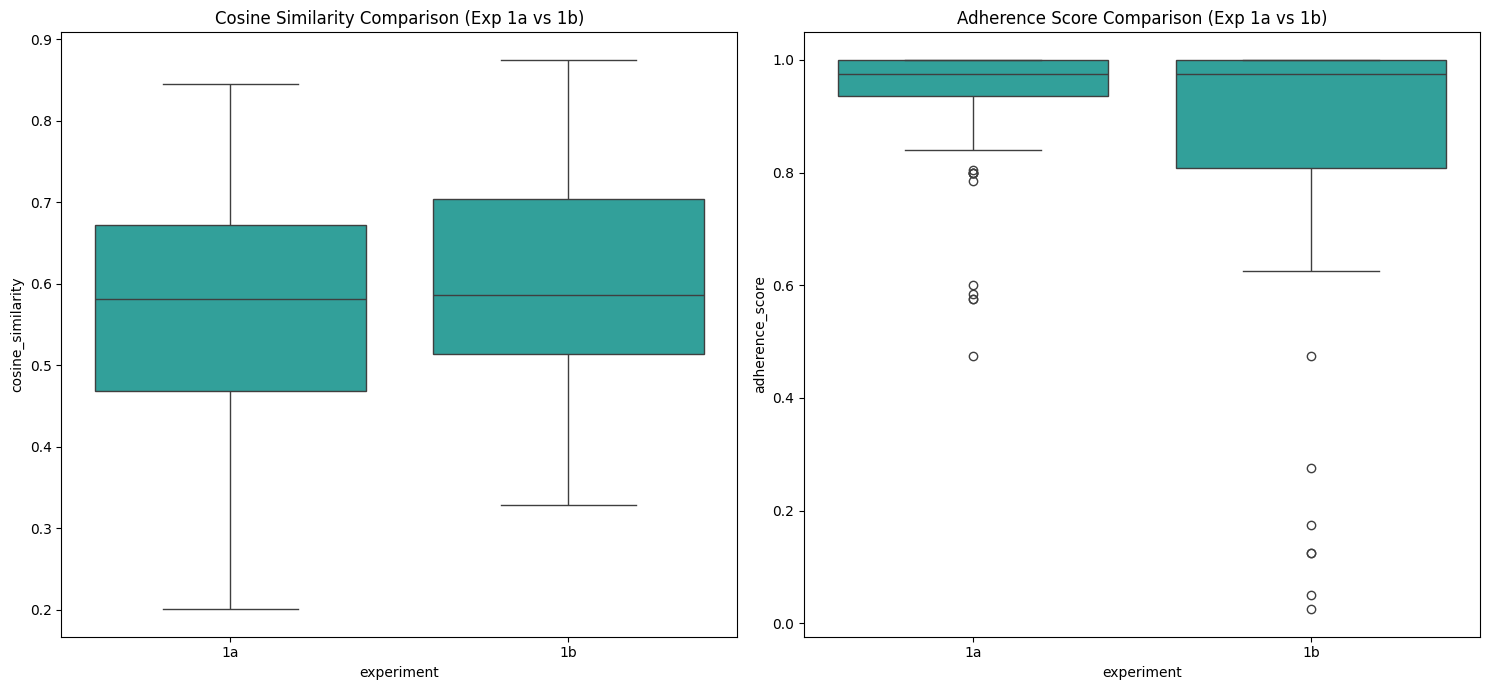

In [70]:
# Add experiment column to each dataframe
exp1a_df['experiment'] = '1a'
exp1b_df['experiment'] = '1b'

# Concatenate the two dataframes
combined_df = pd.concat([exp1a_df, exp1b_df])

# Boxplot for cosine_similarity and adherence_score by experiment
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plots['exp1_comparison'] = fig

sns.boxplot(x='experiment', y='cosine_similarity', data=combined_df, ax=ax[0], color='lightseagreen')
ax[0].set_title('Cosine Similarity Comparison (Exp 1a vs 1b)')

sns.boxplot(x='experiment', y='adherence_score', data=combined_df, ax=ax[1], color='lightseagreen')
ax[1].set_title('Adherence Score Comparison (Exp 1a vs 1b)')

plt.tight_layout()
plt.show()


In [71]:
# # Question Type comparison between experiments
# fig, ax = plt.subplots(2, 2, figsize=(20, 12))
# plots['exp1_question_type_comparison'] = fig

# # Plot 1: Cosine similarity by question type and experiment
# sns.boxplot(x='question_type', y='cosine_similarity', hue='experiment', data=combined_df, ax=ax[0,0])
# ax[0,0].set_title('Cosine Similarity by Question Type (Exp 1a vs 1b)')
# ax[0,0].tick_params(axis='x', rotation=45)

# # Plot 2: Adherence score by question type and experiment  
# sns.boxplot(x='question_type', y='adherence_score', hue='experiment', data=combined_df, ax=ax[0,1])
# ax[0,1].set_title('Adherence Score by Question Type (Exp 1a vs 1b)')
# ax[0,1].tick_params(axis='x', rotation=45)

# # Plot 3: Count of question types per experiment
# question_type_counts = combined_df.groupby(['experiment', 'question_type']).size().unstack(fill_value=0)
# question_type_counts.plot(kind='bar', ax=ax[1,0], color=['lightblue', 'lightgreen', 'lightcoral'])
# ax[1,0].set_title('Question Type Distribution by Experiment')
# ax[1,0].set_ylabel('Count')
# ax[1,0].tick_params(axis='x', rotation=0)

# # Plot 4: For MC questions only - comparison by correct answers count
# mc_combined = combined_df[combined_df['question_type'] == 'multiple_choice'].copy()
# if not mc_combined.empty:
#     sns.boxplot(x='correct_answers_count', y='cosine_similarity', hue='experiment', data=mc_combined, ax=ax[1,1])
#     ax[1,1].set_title('MC Questions: Cosine Similarity by Correct Answers Count')
# else:
#     ax[1,1].text(0.5, 0.5, 'No MC questions found', ha='center', va='center', transform=ax[1,1].transAxes)
#     ax[1,1].set_title('MC Questions Analysis')

# plt.tight_layout()
# plt.show()

## Experiment 1b

### 2.1: Metrics by LLM

In [72]:
llm_metrics_1b = exp1b_df.groupby("llm")[["cosine_similarity", "adherence_score"]].agg(
    ["mean", "std"]
)
tables["exp1b_metrics_by_llm"] = llm_metrics_1b
display(llm_metrics_1a)


cosine_similarity           adherence_score          
                       mean       std            mean       std
llm                                                            
anthropic          0.578823  0.136459        0.935238  0.110993
deepseek           0.490059  0.142076        0.958690  0.049879
google             0.634277  0.142834        0.940714  0.079300
openai             0.543139  0.154746        0.965833  0.083731

### 2.2: Metrics by Input Source

In [73]:
input_source_metrics_1b = exp1b_df.groupby("input_source")[
    ["cosine_similarity", "adherence_score"]
].agg(["mean", "std"])
tables["exp1b_metrics_by_input_source"] = input_source_metrics_1b
display(input_source_metrics_1b)

cosine_similarity           adherence_score          
                                mean       std            mean       std
input_source                                                            
script_manipulated          0.598388  0.129878        0.840268  0.273503

### 2.3: Metrics by Prompt Type

In [74]:
prompt_type_metrics_1b = exp1b_df.groupby("prompt_type")[
    ["cosine_similarity", "adherence_score"]
].agg(["mean", "std"])
tables["exp1b_metrics_by_prompt_type"] = prompt_type_metrics_1b
display(prompt_type_metrics_1b)

cosine_similarity           adherence_score          
                         mean       std            mean       std
prompt_type                                                      
common               0.621259  0.137741        0.951250  0.170368
complex              0.575516  0.119598        0.729286  0.312741

### 2.4: Metrics by Layer

In [75]:
layer_metrics_1b = exp1b_df.groupby("layer")[["cosine_similarity", "adherence_score"]].agg(
    ["mean", "std"]
)
tables["exp1b_metrics_by_layer"] = layer_metrics_1b
display(layer_metrics_1b)

cosine_similarity           adherence_score          
                   mean       std            mean       std
layer                                                      
1              0.574804  0.096853        0.771875  0.385866
2              0.542807  0.150093        0.829375  0.311063
3              0.616298  0.103107        0.760625  0.273750
4              0.553682  0.110393        0.929375  0.082870
5              0.622286  0.137674        0.836250  0.326964
6              0.573622  0.083204        0.817500  0.334055
7              0.705217  0.175271        0.936875  0.093310

### 2.5: Metrics by Question Type

In [76]:
# question_type_metrics_1b = exp1b_df.groupby("question_type")[["cosine_similarity", "adherence_score"]].agg(
#     ["mean", "std", "count"]
# )
# tables["exp1b_metrics_by_question_type"] = question_type_metrics_1b
# display(question_type_metrics_1b)

### 2.6: Multiple Choice Questions - Metrics by Number of Correct Answers

In [77]:
# # Filter for multiple choice questions only
# mc_questions_1b = exp1b_df[exp1b_df['question_type'] == 'multiple_choice'].copy()

# if not mc_questions_1b.empty:
#     # Metrics by number of correct answers
#     correct_answers_metrics_1b = mc_questions_1b.groupby("correct_answers_count")[["cosine_similarity", "adherence_score"]].agg(
#         ["mean", "std", "count"]
#     )
#     tables["exp1b_mc_metrics_by_correct_answers"] = correct_answers_metrics_1b
#     display(correct_answers_metrics_1b)
    
#     # # Metrics by total number of options
#     # total_options_metrics_1b = mc_questions_1b.groupby("total_options_count")[["cosine_similarity", "adherence_score"]].agg(
#     #     ["mean", "std", "count"]
#     # )
#     # tables["exp1b_mc_metrics_by_total_options"] = total_options_metrics_1b
#     # display(total_options_metrics_1b)
# else:
#     print("No multiple choice questions found in exp1b")

### 2.5: Cosine Similarity: LLM vs Input Source

In [78]:
llm_vs_input_source_cos_sim_1b = pd.pivot_table(
    exp1b_df,
    values="cosine_similarity",
    index="llm",
    columns="input_source",
    aggfunc=["mean", "std"],
)
tables["exp1b_cosine_sim_llm_vs_input_source"] = llm_vs_input_source_cos_sim_1b
display(llm_vs_input_source_cos_sim_1b)

,mean,std
input_source,script_manipulated,script_manipulated
llm,,
anthropic,0.639624,0.120503
deepseek,0.535659,0.120614
google,0.618493,0.155956
openai,0.599776,0.107091


In [79]:

# fig, ax = plt.subplots(figsize=(10, 6))
# plots['exp1b_cosine_sim_llm_vs_input_source'] = fig
# sns.heatmap(llm_vs_input_source_cos_sim_1b["mean"], annot=True, fmt=".2f", cmap="viridis", ax=ax)
# ax.set_title("Mean Cosine Similarity: LLM vs Input Source (Exp 1b)")
# plt.show()


### 2.6: Cosine Similarity: LLM vs Prompt Type

In [80]:
llm_vs_prompt_type_cos_sim_1b = pd.pivot_table(
    exp1b_df,
    values="cosine_similarity",
    index="llm",
    columns="prompt_type",
    aggfunc=["mean", "std"],
)
tables["exp1b_cosine_sim_llm_vs_prompt_type"] = llm_vs_prompt_type_cos_sim_1b
display(llm_vs_prompt_type_cos_sim_1b)

mean                 std          
prompt_type    common   complex    common   complex
llm                                                
anthropic    0.702068  0.577180  0.139379  0.054194
deepseek     0.532872  0.538446  0.123492  0.127482
google       0.648236  0.588749  0.150385  0.167388
openai       0.601861  0.597690  0.100315  0.121553

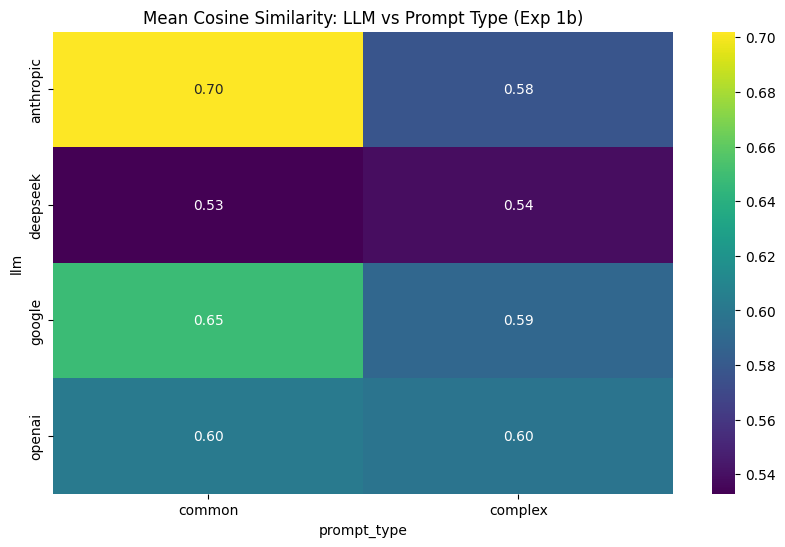

In [81]:

fig, ax = plt.subplots(figsize=(10, 6))
plots['exp1b_cosine_sim_llm_vs_prompt_type'] = fig
sns.heatmap(llm_vs_prompt_type_cos_sim_1b["mean"], annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Mean Cosine Similarity: LLM vs Prompt Type (Exp 1b)")
plt.show()


### 2.7: Adherence Score: LLM vs Prompt Type

In [82]:
llm_vs_prompt_type_adherence_1b = pd.pivot_table(
    exp1b_df,
    values="adherence_score",
    index="llm",
    columns="prompt_type",
    aggfunc=["mean", "std"],
)
tables["exp1b_adherence_llm_vs_prompt_type"] = llm_vs_prompt_type_adherence_1b
display(llm_vs_prompt_type_adherence_1b)

mean                 std          
prompt_type    common   complex    common   complex
llm                                                
anthropic    0.950000  0.857143  0.101036  0.132817
deepseek     0.864286  0.597857  0.326553  0.355585
google       0.997857  0.842857  0.005669  0.173850
openai       0.992857  0.619286  0.018898  0.444339

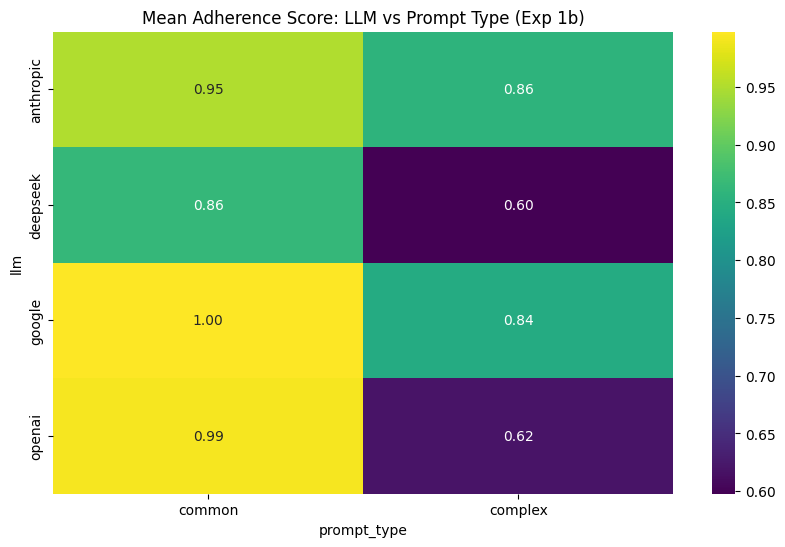

In [83]:

fig, ax = plt.subplots(figsize=(10, 6))
plots['exp1b_adherence_llm_vs_prompt_type'] = fig
sns.heatmap(llm_vs_prompt_type_adherence_1b["mean"], annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Mean Adherence Score: LLM vs Prompt Type (Exp 1b)")
plt.show()


### 2.8: Adherence Score: LLM vs Input Source

In [84]:
llm_vs_input_source_adherence_1b = pd.pivot_table(
    exp1b_df,
    values="adherence_score",
    index="llm",
    columns="input_source",
    aggfunc=["mean", "std"],
)
tables["exp1b_adherence_llm_vs_input_source"] = llm_vs_input_source_adherence_1b
display(llm_vs_input_source_adherence_1b)

,mean,std
input_source,script_manipulated,script_manipulated
llm,,
anthropic,0.903571,0.123186
deepseek,0.731071,0.355929
google,0.920357,0.142942
openai,0.806071,0.358974


## Save all tables and plots

In [85]:
def save_all_tables_and_plots():
    # Save tables
    for name, df in tables.items():
        if name.startswith("exp1a"):
            output_dir = output_dir_exp1a
            table_name = name.replace("exp1a_", "")
        elif name.startswith("exp1b"):
            output_dir = output_dir_exp1b
            table_name = name.replace("exp1b_", "")
        else:
            # For combined analyses, save to both directories
            if "exp1" in name:
                # Save to exp1a directory with full name
                base_filename = os.path.join(output_dir_exp1a, name)
                csv_path = f"{base_filename}.csv"
                df.to_csv(csv_path)
                print(f"Saved {csv_path}")
            continue

        base_filename = os.path.join(output_dir, table_name)
        
        # Save to CSV
        csv_path = f"{base_filename}.csv"
        df.to_csv(csv_path)
        print(f"Saved {csv_path}")

    # Save plots
    for name, fig in plots.items():
        if name.startswith("exp1a"):
            output_dir = output_plot_dir_exp1a
            plot_name = name.replace("exp1a_", "")
        elif name.startswith("exp1b"):
            output_dir = output_plot_dir_exp1b
            plot_name = name.replace("exp1b_", "")
        else:
            # For combined analyses, save to exp1a directory with full name
            if "exp1" in name:
                base_filename = os.path.join(output_plot_dir_exp1a, name)
                png_path = f"{base_filename}.png"
                fig.savefig(png_path, bbox_inches='tight')
                print(f"Saved {png_path}")
            continue
        
        base_filename = os.path.join(output_dir, plot_name)
        
        # Save to PNG
        png_path = f"{base_filename}.png"
        fig.savefig(png_path, bbox_inches='tight')
        print(f"Saved {png_path}")

save_all_tables_and_plots()

Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/metrics_by_llm.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/metrics_by_input_source.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/metrics_by_prompt_type.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/metrics_by_layer.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/cosine_sim_llm_vs_input_source.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/cosine_sim_llm_vs_prompt_type.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/adherence_llm_vs_prompt_type.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/adherence_llm_vs_input_source.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1b/metrics_by_llm.csv
Sav